In [1]:
import numpy as np
from utils import analytic, tf

## Άσκηση — Διαμόρφωση πλάτους AM (Amplitude Modulation)

Στη **συνήθη διαμόρφωση πλάτους (AM)**, το πλάτος ενός φέροντος υψηλής συχνότητας μεταβάλλεται ανάλογα με το μήνυμα, ενώ διατηρείται και μια **συνιστώσα φέροντος**. 

Με μήνυμα $$m(t)=A_m\cos(\omega_m t)$$ και φέρον $$c(t)=A_c\cos(\omega_c t)$$ το σήμα AM είναι:

$$s(t) = A_c\big[1 + \mu\cos(\omega_m t)\big]\cos(\omega_c t), \qquad \mu=\frac{A_m}{A_c}\le 1 \tag{1}$$

όπου $\mu$ ο περίφημος **δείκτης διαμόρφωσης**. Αναπτύσσοντας το γινόμενο (τριγωνομετρική ταυτότητα $\cos a\cos b=\tfrac12[\cos(a\!-\!b)+\cos(a\!+\!b)]$):

$$s(t) = \underbrace{A_c\cos(\omega_c t)}_{\text{φέρον}} + \underbrace{\tfrac{\mu A_c}{2}\cos((\omega_c\!-\!\omega_m)t)}_{\text{κάτω πλευρική}} + \underbrace{\tfrac{\mu A_c}{2}\cos((\omega_c\!+\!\omega_m)t)}_{\text{άνω πλευρική}} \tag{2}$$

**Στο πεδίο της συχνότητας** εμφανίζονται τρεις γραμμές: το **φέρον** στο $f_c$ και οι δύο **πλευρικές** στα $f_c\pm f_m$. Το εύρος ζώνης είναι $W_B=2f_m$.

* **Πλεονέκτημα:** αν $\mu\le 1$, η περιβάλλουσα $A_c[1+\mu\cos\omega_m t]$ παραμένει θετική, οπότε η αποδιαμόρφωση γίνεται με απλό **ανιχνευτή περιβάλλουσας** (φθηνός δέκτης).
* **Μειονέκτημα:** το φέρον δεν μεταφέρει πληροφορία αλλά καταναλώνει ισχύ: η αποδοτικότητα είναι $\eta=\dfrac{\mu^2}{2+\mu^2}$, δηλαδή το πολύ $33\%$ για $\mu=1$.

Σε όσα ακολουθούν, απεικονίζουμε μόνο τα φάσματα στο θετικό ημιάξονα των συχνοτήτων.

### i. Μήνυμα και φέρον

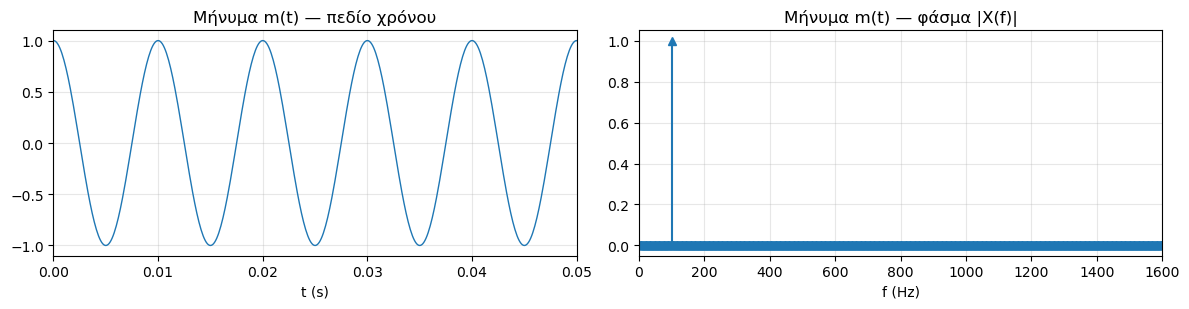

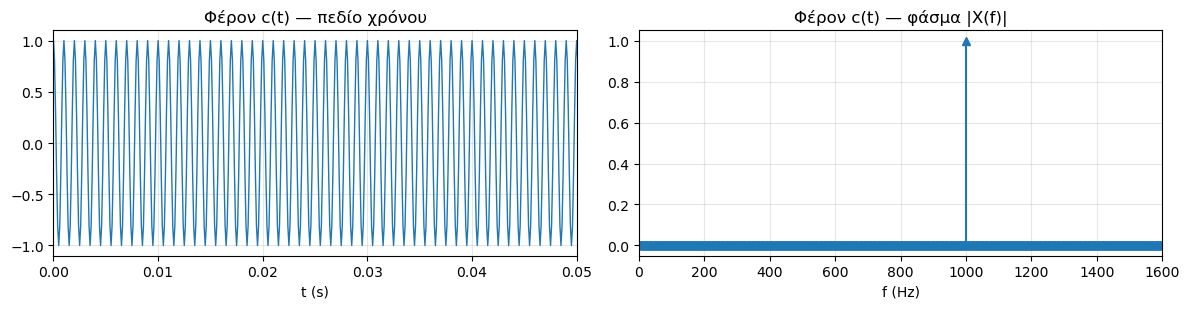

In [2]:
# ----- Παράμετροι (κοινές) -----
fs = 10000          # συχνότητα δειγματοληψίας (Hz)
N  = 4000           # πλήθος δειγμάτων (0.4 s)
t  = np.arange(N)/fs
fm = 100            # συχνότητα μηνύματος (Hz)
fc = 1000           # συχνότητα φέροντος (Hz)
Am = 1.0            # πλάτος μηνύματος
Ac = 1.0            # πλάτος φέροντος
wm = 2*np.pi*fm
wc = 2*np.pi*fc

m = Am*np.cos(wm*t)         # μήνυμα (ημιτονοειδές)
carrier = Ac*np.cos(wc*t)   # φέρον

mu = 0.7   # δείκτης διαμόρφωσης (< 1)

tf(m, fs, 'Μήνυμα m(t)')
tf(carrier, fs, 'Φέρον c(t)')

### ii. Παραγωγή του σήματος AM

Υλοποιήστε απευθείας τη Σχέση (1):

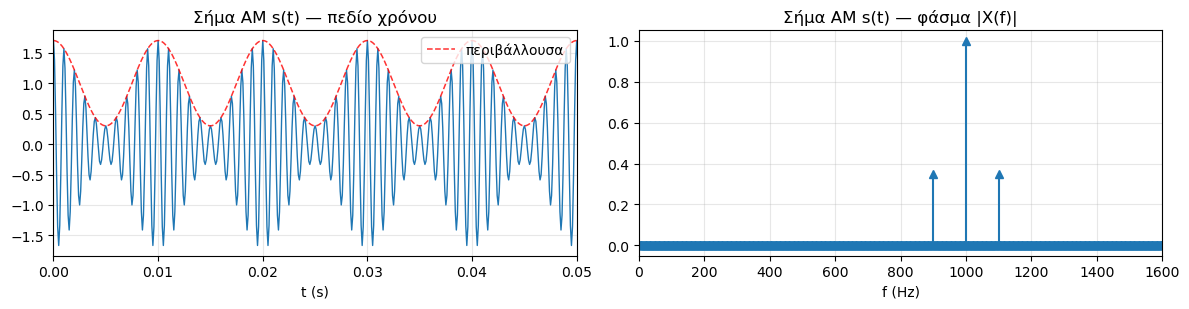

In [3]:
s = Ac * (1 + mu*np.cos(wm*t)) * np.cos(wc*t) # INSERT CODE HERE
env_theory = Ac*(1 + mu*np.cos(wm*t))   # θεωρητική περιβάλλουσα

tf(s, fs, 'Σήμα AM s(t)', ref=env_theory)

### iii. Αποδιαμόρφωση με ανιχνευτή περιβάλλουσας

Η ιδανική περιβάλλουσα δίνεται από το μέτρο του **αναλυτικού σήματος**: 

$$e(t)=|s(t)+j\hat s(t)| = A_c[1+\mu\cos\omega_m t]$$

με $\hat{s}(t)$ το **μετασχ. Hilbert** του σήματος.

Αφαιρώντας τη **DC** συνιστώσα και κανονικοποιώντας ανακτούμε το μήνυμα.

$$ e(t)=A_c\big[1+\mu\cos(\omega_m t)\big] \;\xrightarrow{\text{αφαίρεση DC}}\; \mu A_c\cos(\omega_m t)\ \propto\ m(t) \tag{3}$$

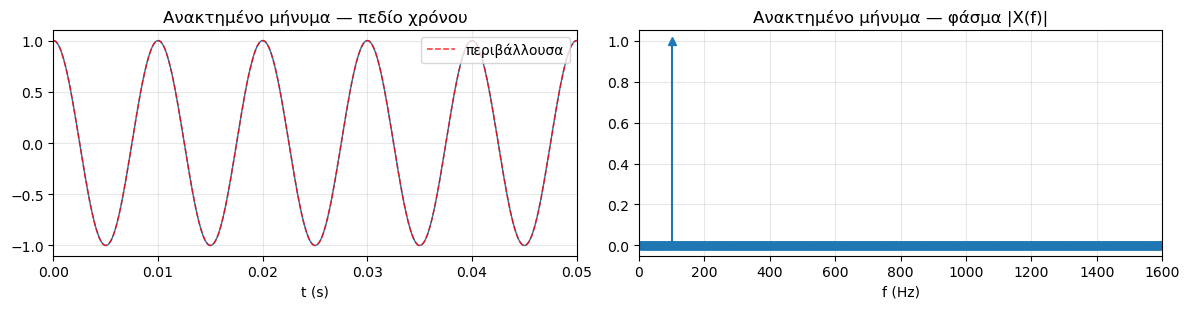

Το μέγιστο σφάλμα ανάκτησης ισούται με: 7.984e-13


In [4]:
env = np.abs(analytic(s))          # ανιχνευτής περιβάλλουσας μέσω του μέτρου του μετασχ. Hilbert
rec = env - np.mean(env)           # αφαίρεση DC
rec = rec / (mu*Ac)                # κανονικοποίηση -> m(t)

tf(rec, fs, 'Ανακτημένο μήνυμα', ref=m)

# ποσοτικός έλεγχος (μακριά από τα άκρα)
sl = slice(200, N-200)
err = np.max(np.abs(rec[sl]-m[sl]))
print(f'Το μέγιστο σφάλμα ανάκτησης ισούται με: {err:.3e}')

### Παρατηρήσεις

Το φάσμα του AM επιβεβαιώνει τη Σχέση (2): μια ισχυρή γραμμή φέροντος στα $f_c=1000$ Hz και δύο πλευρικές μισού πλάτους στα $900$ και $1100$ Hz. Στο πεδίο του χρόνου η περιβάλλουσα (κόκκινη διακεκομμένη) ακολουθεί πιστά το μήνυμα, ακριβώς επειδή $\mu=0.7<1$ και δεν υπάρχει **υπερδιαμόρφωση**. Έτσι ο ανιχνευτής περιβάλλουσας ανακτά το μήνυμα με αμελητέο σφάλμα, χωρίς να χρειάζεται συγχρονισμένο τοπικό ταλαντωτή. Το τίμημα είναι η σπατάλη ισχύος στο φέρον (αποδοτικότητα $\le 33\%$), κάτι που θεραπεύουν οι επόμενες τεχνικές (DSB-SC, SSB) που θα δείτε σε σχετικές ασκήσεις στο ίδιο Κεφάλαιο.

---
---